# IronClad Case Study
# Task 5: Optimizing the number of gallery images per identity

This notebook investigates how to find an optimal number of gallery images stored per identity to maximize identification performance. Because increasing the minimum number of required images per identity ($m$) simultaneously enriches the gallery representation and reduces the number of eligible identities, a naive experiment would conflate these two effects. 

The notebook therefore implements two complementary experimental designs: 

-The first is a coverage tradeoff experiment: for each $m$ from 1 to 10, only identities with at least $m$ gallery images are retained, exactly $m$ images are sampled per identity, and Top-1 and Top-5 accuracy are evaluated over three random seeds under exact Brute Force retrieval. 

-The second is a constant identity set experiment: the 51 identities that have all 10 gallery images are held fixed throughout, and only the number of sampled images per identity varies, isolating the true effect of gallery depth from identity attrition. 

Both experiments are run for `casia-webface` and `vggface2` under both baseline and MTCNN preprocessing, so the notebook also reveals whether stronger preprocessing shifts the recommended $m$. A plateau-detection rule selects the smallest $m$ at which Top-1 accuracy reaches within one percentage point of the observed maximum.

## Imports and configuration

In [1]:
import sys, subprocess, importlib, os, json
import numpy as np
import pandas as pd
import time
from pathlib import Path
from PIL import Image, UnidentifiedImageError

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

def _ensure(import_name: str, pip_name: str = None):
    pip_name = pip_name or import_name
    try:
        importlib.import_module(import_name)
        print(f"✓ {import_name} already installed")
    except Exception:
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
        importlib.import_module(import_name)
        print(f"✓ Installed {import_name}")

_ensure("faiss", "faiss-cpu")
_ensure("tqdm", "tqdm")
_ensure("facenet_pytorch", "facenet-pytorch")

import torch
from tqdm.auto import tqdm
import faiss

import types
if "torch.utils.serialization" not in sys.modules:
    sys.modules["torch.utils.serialization"] = types.ModuleType("torch.utils.serialization")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("CUDA available:", torch.cuda.is_available(), "| DEVICE:", DEVICE)
np.random.seed(42)


✓ faiss already installed
✓ tqdm already installed
✓ facenet_pytorch already installed
CUDA available: False | DEVICE: cpu


In [2]:
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ironclad.modules.extraction.preprocessing import Preprocessing
from ironclad.modules.extraction.embedding import Embedding
from ironclad.modules.retrieval.index.bruteforce import FaissBruteForce
from ironclad.modules.retrieval.index.hnsw import FaissHNSW
from ironclad.modules.retrieval.index.lsh import FaissLSH
from ironclad.modules.retrieval.search import FaissSearch
from facenet_pytorch import MTCNN

print("Project root:", PROJECT_ROOT)

MTCNN_THRESHOLD = 0.80
MTCNN_MARGIN = 20
METRIC = "cosine"


Project root: C:\Users\Usuario\Downloads\ironclad-hortner87-main(1)\ironclad-hortner87-main


In [3]:
STORAGE_ROOT = PROJECT_ROOT / "ironclad" / "storage"
GALLERY_DIR = STORAGE_ROOT / "gallery"
PROBE_DIR = STORAGE_ROOT / "probe"

print("Gallery dir:", GALLERY_DIR)
print("Probe dir  :", PROBE_DIR)

if not (GALLERY_DIR.exists() and PROBE_DIR.exists()):
    raise FileNotFoundError("Expected BASE/ironclad/storage/{gallery,probe}")

def list_images_by_identity(base_dir: Path):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    out = {}
    for ident_dir in sorted([p for p in base_dir.iterdir() if p.is_dir()]):
        imgs = []
        for p in ident_dir.rglob("*"):
            if not p.is_file():
                continue
            if p.suffix.lower() not in exts:
                continue
            if p.name.startswith("._") or p.name.startswith("."):
                continue
            imgs.append(p)
        if imgs:
            out[ident_dir.name] = sorted(imgs)
    return out

gallery = list_images_by_identity(GALLERY_DIR)
probe = list_images_by_identity(PROBE_DIR)
overlap = sorted(set(gallery.keys()) & set(probe.keys()))

print("Identities in gallery:", len(gallery))
print("Identities in probe  :", len(probe))
print("Overlap identities   :", len(overlap))


Gallery dir: C:\Users\Usuario\Downloads\ironclad-hortner87-main(1)\ironclad-hortner87-main\ironclad\storage\gallery
Probe dir  : C:\Users\Usuario\Downloads\ironclad-hortner87-main(1)\ironclad-hortner87-main\ironclad\storage\probe
Identities in gallery: 1000
Identities in probe  : 999
Overlap identities   : 999


In [4]:
preproc = Preprocessing(image_size=160)
CACHE_DIR = Path.cwd() / "cache_mtcnn_shared"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

mtcnn = MTCNN(
    image_size=160,
    margin=MTCNN_MARGIN,
    keep_all=True,
    device=DEVICE
)

def pil_load_rgb(path: Path):
    try:
        return Image.open(path).convert("RGB")
    except (UnidentifiedImageError, OSError):
        return None

DETECTION_CACHE_PATH = CACHE_DIR / "mtcnn_detection_cache.json"
if DETECTION_CACHE_PATH.exists():
    with open(DETECTION_CACHE_PATH, "r", encoding="utf-8") as f:
        DET_CACHE = json.load(f)
else:
    DET_CACHE = {}

def _save_det_cache():
    with open(DETECTION_CACHE_PATH, "w", encoding="utf-8") as f:
        json.dump(DET_CACHE, f)

def detect_best_face(path: Path):
    key = str(path)
    if key in DET_CACHE:
        rec = DET_CACHE[key]
        box = rec["box"]
        prob = rec["prob"]
        return (np.array(box, dtype=float) if box is not None else None), prob

    img = pil_load_rgb(path)
    if img is None:
        DET_CACHE[key] = {"box": None, "prob": None}
        _save_det_cache()
        return None, None

    boxes, probs = mtcnn.detect(img)
    if boxes is None or probs is None or len(boxes) == 0:
        DET_CACHE[key] = {"box": None, "prob": None}
        _save_det_cache()
        return None, None

    best = int(np.argmax(probs))
    box = boxes[best].tolist()
    prob = float(probs[best]) if probs[best] is not None else None
    DET_CACHE[key] = {"box": box, "prob": prob}
    _save_det_cache()
    return np.array(box, dtype=float), prob

def crop_from_box(img: Image.Image, box, margin_px=MTCNN_MARGIN):
    x1, y1, x2, y2 = [float(v) for v in box]
    x1 = max(0, int(np.floor(x1)) - margin_px)
    y1 = max(0, int(np.floor(y1)) - margin_px)
    x2 = min(img.width, int(np.ceil(x2)) + margin_px)
    y2 = min(img.height, int(np.ceil(y2)) + margin_px)
    if x2 <= x1 or y2 <= y1:
        return img
    return img.crop((x1, y1, x2, y2))

def get_variant_image(path: Path, variant: str = "baseline", threshold: float = MTCNN_THRESHOLD):
    img = pil_load_rgb(path)
    if img is None:
        return None, None, False
    if variant == "baseline":
        return img, None, False

    box, prob = detect_best_face(path)
    use_crop = box is not None and prob is not None and prob >= threshold
    if use_crop:
        return crop_from_box(img, box, margin_px=MTCNN_MARGIN), prob, True
    else:
        return img, prob, False

def l2_normalize(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(norms, eps)

def embed_split(model_name: str, paths, labels, split_name: str, variant: str = "baseline", threshold: float = MTCNN_THRESHOLD):
    key_src = f"{model_name}|{split_name}|{variant}|{threshold}|{len(paths)}"
    key = str(abs(hash(key_src)))
    cache_path = CACHE_DIR / f"emb_{model_name}_{split_name}_{variant}_{key}.npz"
    if cache_path.exists():
        z = np.load(cache_path, allow_pickle=True)
        return (
            z["X"].astype(np.float32),
            z["labels"].tolist(),
            [Path(p) for p in z["paths"].tolist()],
            dict(
                crop_rate=float(z["crop_rate"][0]),
                mean_conf=float(z["mean_conf"][0]) if len(z["mean_conf"]) else np.nan,
                n_images=int(z["n_images"][0]),
            )
        )

    model = Embedding(pretrained=model_name, device=DEVICE)
    vecs, labs, keep_paths = [], [], []
    confs, used_crop = [], []
    for p, lab in tqdm(list(zip(paths, labels)), desc=f"Embedding {split_name} | {model_name} | {variant}"):
        img_variant, conf, did_crop = get_variant_image(p, variant=variant, threshold=threshold)
        if img_variant is None:
            continue
        tens = preproc.process(img_variant)
        vec = model.encode(tens).astype(np.float32)
        vecs.append(vec)
        labs.append(lab)
        keep_paths.append(str(p))
        if conf is not None:
            confs.append(float(conf))
        used_crop.append(bool(did_crop))

    X = np.vstack([v.reshape(1, -1) for v in vecs]).astype(np.float32)
    X = l2_normalize(X)
    crop_rate = float(np.mean(used_crop)) if used_crop else 0.0
    mean_conf = float(np.mean(confs)) if confs else np.nan

    np.savez(
        cache_path,
        X=X,
        labels=np.array(labs, dtype=object),
        paths=np.array(keep_paths, dtype=object),
        crop_rate=np.array([crop_rate], dtype=np.float32),
        mean_conf=np.array([mean_conf], dtype=np.float32),
        n_images=np.array([len(labs)], dtype=np.int32),
    )
    return X, labs, [Path(p) for p in keep_paths], dict(crop_rate=crop_rate, mean_conf=mean_conf, n_images=len(labs))


In [5]:
gal_counts = pd.Series({k: len(v) for k, v in gallery.items()})
prb_counts = pd.Series({k: len(v) for k, v in probe.items()})
stats_df = pd.DataFrame({"gallery_images": gal_counts, "probe_images": prb_counts}).fillna(0).astype(int)
stats_df = stats_df.loc[overlap]
stats_df.describe()


,gallery_images,probe_images
count,999.000000,999.0
mean,2.263263,1.0
std,2.356452,0.0
min,1.000000,1.0
25%,1.000000,1.0
50%,1.000000,1.0
75%,3.000000,1.0
max,10.000000,1.0


### Embedding Pipeline 

In [6]:
gallery_pairs = []
for ident in overlap:
    for p in gallery[ident]:
        gallery_pairs.append((p, ident))

probe_pairs = []
for ident in overlap:
    for p in probe[ident]:
        probe_pairs.append((p, ident))

MODELS = ["casia-webface", "vggface2"]
PREPROC_VARIANTS = ["baseline", "mtcnn"]

embedded = {}
paths_g, labels_g = zip(*gallery_pairs)
paths_p, labels_p = zip(*probe_pairs)
for model_name in MODELS:
    embedded[model_name] = {}
    for variant in PREPROC_VARIANTS:
        Xg, yg, pg, gstats = embed_split(model_name, list(paths_g), list(labels_g), "gallery_all", variant=("baseline" if variant=="baseline" else "mtcnn"))
        Xp, yp, pp, pstats = embed_split(model_name, list(paths_p), list(labels_p), "probe_all", variant=("baseline" if variant=="baseline" else "mtcnn"))
        embedded[model_name][variant] = {"gal_X": Xg, "gal_y": yg, "prb_X": Xp, "prb_y": yp}
        print(model_name, variant, Xg.shape, Xp.shape)


Embedding gallery_all | casia-webface | baseline:   0%|          | 0/2261 [00:00<?, ?it/s]

Embedding probe_all | casia-webface | baseline:   0%|          | 0/999 [00:00<?, ?it/s]

casia-webface baseline (2261, 512) (999, 512)


Embedding gallery_all | casia-webface | mtcnn:   0%|          | 0/2261 [00:00<?, ?it/s]

Embedding probe_all | casia-webface | mtcnn:   0%|          | 0/999 [00:00<?, ?it/s]

...

Embedding probe_all | vggface2 | baseline:   0%|          | 0/999 [00:00<?, ?it/s]

vggface2 baseline (2261, 512) (999, 512)


Embedding gallery_all | vggface2 | mtcnn:   0%|          | 0/2261 [00:00<?, ?it/s]

Embedding probe_all | vggface2 | mtcnn:   0%|          | 0/999 [00:00<?, ?it/s]

vggface2 mtcnn (2261, 512) (999, 512)


### Experiment design

In [7]:
def indices_by_identity(labels):
    idxs = {}
    for i, lab in enumerate(labels):
        idxs.setdefault(lab, []).append(i)
    return idxs

def eval_for_m_coverage(model_name, variant, m, seeds=(0,1,2), k_values=(1,5)):
    data = embedded[model_name][variant]
    gal_X, gal_y = data["gal_X"], data["gal_y"]
    prb_X, prb_y = data["prb_X"], data["prb_y"]
    gal_map = indices_by_identity(gal_y)
    eligible = sorted([ident for ident, idxs in gal_map.items() if len(idxs) >= m])
    eligible_set = set(eligible)
    prb_keep = [i for i, lab in enumerate(prb_y) if lab in eligible_set]
    prb_X_m = prb_X[prb_keep]
    prb_y_m = [prb_y[i] for i in prb_keep]
    rows = []
    for seed in seeds:
        rng = np.random.default_rng(seed)
        sel_indices, sel_meta = [], []
        for ident in eligible:
            choices = rng.choice(gal_map[ident], size=m, replace=False)
            sel_indices.extend(choices.tolist())
            sel_meta.extend([ident] * m)
        Xg = gal_X[sel_indices]
        bf = FaissBruteForce(dim=Xg.shape[1], metric=METRIC)
        bf.add_embeddings(Xg, sel_meta)
        _, I = bf.index.search(prb_X_m.astype(np.float32), max(k_values))
        for k in k_values:
            correct = 0
            for qi in range(prb_X_m.shape[0]):
                preds = [bf.get_metadata(int(j)) for j in I[qi, :k] if int(j) >= 0]
                if prb_y_m[qi] in preds:
                    correct += 1
            rows.append({"model":model_name,"preprocessing":variant,"experiment":"coverage_tradeoff",
                         "m":m,"seed":seed,"k":k,"topk_accuracy":correct/prb_X_m.shape[0] if prb_X_m.shape[0] else np.nan,
                         "n_identities":len(eligible),"n_gallery_vectors":len(sel_indices),"n_probe_images":prb_X_m.shape[0]})
    return pd.DataFrame(rows)

def eval_for_m_constant(model_name, variant, m_values, m_max=None, seeds=(0,1,2), k_values=(1,5)):
    data = embedded[model_name][variant]
    gal_X, gal_y = data["gal_X"], data["gal_y"]
    prb_X, prb_y = data["prb_X"], data["prb_y"]
    gal_map = indices_by_identity(gal_y)
    if m_max is None:
        m_max = max(m_values)
    const_identities = sorted([ident for ident, idxs in gal_map.items() if len(idxs) >= m_max])
    const_set = set(const_identities)
    prb_keep = [i for i, lab in enumerate(prb_y) if lab in const_set]
    prb_X_c = prb_X[prb_keep]
    prb_y_c = [prb_y[i] for i in prb_keep]
    rows = []
    for m in m_values:
        for seed in seeds:
            rng = np.random.default_rng(seed)
            sel_indices, sel_meta = [], []
            for ident in const_identities:
                choices = rng.choice(gal_map[ident], size=m, replace=False)
                sel_indices.extend(choices.tolist())
                sel_meta.extend([ident] * m)
            Xg = gal_X[sel_indices]
            bf = FaissBruteForce(dim=Xg.shape[1], metric=METRIC)
            bf.add_embeddings(Xg, sel_meta)
            _, I = bf.index.search(prb_X_c.astype(np.float32), max(k_values))
            for k in k_values:
                correct = 0
                for qi in range(prb_X_c.shape[0]):
                    preds = [bf.get_metadata(int(j)) for j in I[qi, :k] if int(j) >= 0]
                    if prb_y_c[qi] in preds:
                        correct += 1
                rows.append({"model":model_name,"preprocessing":variant,"experiment":"constant_identity_set",
                             "m":m,"seed":seed,"k":k,"topk_accuracy":correct/prb_X_c.shape[0] if prb_X_c.shape[0] else np.nan,
                             "n_identities":len(const_identities),"n_gallery_vectors":len(sel_indices),"n_probe_images":prb_X_c.shape[0]})
    return pd.DataFrame(rows)


In [8]:
max_m = int(stats_df["gallery_images"].max())
M_VALUES = list(range(1, min(max_m, 10) + 1))
M_VALUES


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

### Coverage Tradeoff and Constant Identity Set Results 

In [9]:
rows = []
for model_name in MODELS:
    for variant in PREPROC_VARIANTS:
        for m in tqdm(M_VALUES, desc=f"Coverage-tradeoff | {model_name} | {variant}"):
            rows.append(eval_for_m_coverage(model_name, variant, m=m, seeds=(0,1,2), k_values=(1,5)))
        rows.append(eval_for_m_constant(model_name, variant, m_values=M_VALUES, m_max=max(M_VALUES), seeds=(0,1,2), k_values=(1,5)))
m_df = pd.concat(rows, ignore_index=True)
m_df.head()


Coverage-tradeoff | casia-webface | baseline:   0%|          | 0/10 [00:00<?, ?it/s]

Coverage-tradeoff | casia-webface | mtcnn:   0%|          | 0/10 [00:00<?, ?it/s]

Coverage-tradeoff | vggface2 | baseline:   0%|          | 0/10 [00:00<?, ?it/s]

Coverage-tradeoff | vggface2 | mtcnn:   0%|          | 0/10 [00:00<?, ?it/s]

,model,preprocessing,experiment,m,seed,k,topk_accuracy,n_identities,n_gallery_vectors,n_probe_images
0,casia-webface,baseline,coverage_tradeoff,1,0,1,0.084084,999,999,999
1,casia-webface,baseline,coverage_tradeoff,1,0,5,0.153153,999,999,999
2,casia-webface,baseline,coverage_tradeoff,1,1,1,0.076076,999,999,999
3,casia-webface,baseline,coverage_tradeoff,1,1,5,0.143143,999,999,999
4,casia-webface,baseline,coverage_tradeoff,1,2,1,0.075075,999,999,999


In [10]:
agg = m_df.groupby(["model","preprocessing","experiment","m","k"], as_index=False).agg(
    topk_accuracy_mean=("topk_accuracy","mean"),
    topk_accuracy_std=("topk_accuracy","std"),
    n_identities=("n_identities","first"),
    n_gallery_vectors=("n_gallery_vectors","first"),
    n_probe_images=("n_probe_images","first"),
)
agg


,model,preprocessing,experiment,m,k,topk_accuracy_mean,topk_accuracy_std,n_identities,n_gallery_vectors,n_probe_images
0,casia-webface,baseline,constant_identity_set,1,1,0.143791,0.049345,51,51,51
1,casia-webface,baseline,constant_identity_set,1,5,0.346405,0.045282,51,51,51
2,casia-webface,baseline,constant_identity_set,2,1,0.189542,0.040817,51,102,51
3,casia-webface,baseline,constant_identity_set,2,5,0.437908,0.040817,51,102,51
4,casia-webface,baseline,constant_identity_set,3,1,0.228758,0.068860,51,153,51
5,casia-webface,baseline,constant_identity_set,3,5,0.411765,0.122451,51,153,51
6,casia-webface,baseline,constant_identity_set,4,1,0.215686,0.033962,51,204,51
7,casia-webface,baseline,constant_identity_set,4,5,0.457516,0.063030,51,204,51
8,casia-webface,baseline,constant_identity_set,5,1,0.248366,0.029951,51,255,51
9,casia-webface,baseline,constant_identity_set,5,5,0.529412,0.078431,51,255,51


In [ ]:
### Recommendation and comparison 

In [11]:
def pick_m_plateau(agg_df, model_name, variant, experiment, delta=0.01):
    sub = agg_df[(agg_df["model"] == model_name) &
                 (agg_df["preprocessing"] == variant) &
                 (agg_df["experiment"] == experiment) &
                 (agg_df["k"] == 1)].sort_values("m")
    max_acc = float(sub["topk_accuracy_mean"].max())
    thresh = max_acc - delta
    cand = sub[sub["topk_accuracy_mean"] >= thresh]
    row = cand.iloc[0] if not cand.empty else sub.iloc[-1]
    return {"model": model_name, "preprocessing": variant, "experiment": experiment,
            "recommended_m": int(row["m"]), "top1_at_m": float(row["topk_accuracy_mean"]),
            "max_top1": max_acc, "n_identities_at_m": int(row["n_identities"]),
            "n_probe_images_at_m": int(row["n_probe_images"])}

recs = []
for model_name in MODELS:
    for variant in PREPROC_VARIANTS:
        recs.append(pick_m_plateau(agg, model_name, variant, "coverage_tradeoff"))
        recs.append(pick_m_plateau(agg, model_name, variant, "constant_identity_set"))
rec_df = pd.DataFrame(recs).sort_values(["model","preprocessing","experiment"])
rec_df


,model,preprocessing,experiment,recommended_m,top1_at_m,max_top1,n_identities_at_m,n_probe_images_at_m
1,casia-webface,baseline,constant_identity_set,8,0.320261,0.320261,51,51
0,casia-webface,baseline,coverage_tradeoff,10,0.313725,0.313725,51,51
3,casia-webface,mtcnn,constant_identity_set,6,0.973856,0.980392,51,51
2,casia-webface,mtcnn,coverage_tradeoff,9,0.976190,0.980392,56,56
5,vggface2,baseline,constant_identity_set,6,0.843137,0.849673,51,51
4,vggface2,baseline,coverage_tradeoff,9,0.857143,0.857143,56,56
7,vggface2,mtcnn,constant_identity_set,6,0.980392,0.980392,51,51
6,vggface2,mtcnn,coverage_tradeoff,9,0.982143,0.982143,56,56


In [12]:
combined_rows = []
for model_name in MODELS:
    for variant in PREPROC_VARIANTS:
        const_row = rec_df[(rec_df["model"] == model_name) &
                           (rec_df["preprocessing"] == variant) &
                           (rec_df["experiment"] == "constant_identity_set")].iloc[0]
        m_star = int(const_row["recommended_m"])
        cov_row = agg[(agg["model"] == model_name) &
                      (agg["preprocessing"] == variant) &
                      (agg["experiment"] == "coverage_tradeoff") &
                      (agg["m"] == m_star) &
                      (agg["k"] == 1)].iloc[0]
        combined_rows.append({
            "model": model_name,
            "preprocessing": variant,
            "recommended_m_constant": m_star,
            "top1_constant_at_m": float(const_row["top1_at_m"]),
            "max_top1_constant": float(const_row["max_top1"]),
            "top1_coverage_at_same_m": float(cov_row["topk_accuracy_mean"]),
            "n_identities_coverage": int(cov_row["n_identities"]),
            "n_probe_coverage": int(cov_row["n_probe_images"]),
        })
combined_df = pd.DataFrame(combined_rows).sort_values(["model","preprocessing"])
combined_df


,model,preprocessing,recommended_m_constant,top1_constant_at_m,max_top1_constant,top1_coverage_at_same_m,n_identities_coverage,n_probe_coverage
0,casia-webface,baseline,8,0.320261,0.320261,0.283582,67,67
1,casia-webface,mtcnn,6,0.973856,0.980392,0.941581,97,97
2,vggface2,baseline,6,0.843137,0.849673,0.807560,97,97
3,vggface2,mtcnn,6,0.980392,0.980392,0.951890,97,97


### Final selection

The final selected system from the earlier tasks is based on `vggface2`; the next cell isolates how MTCNN changes the recommended `m` for that model.

In [13]:
selected_df = combined_df[combined_df["model"] == "vggface2"].copy()
selected_df


,model,preprocessing,recommended_m_constant,top1_constant_at_m,max_top1_constant,top1_coverage_at_same_m,n_identities_coverage,n_probe_coverage
2,vggface2,baseline,6,0.843137,0.849673,0.80756,97,97
3,vggface2,mtcnn,6,0.980392,0.980392,0.95189,97,97


### Coverage collapse plot

Using dataframe: m_df


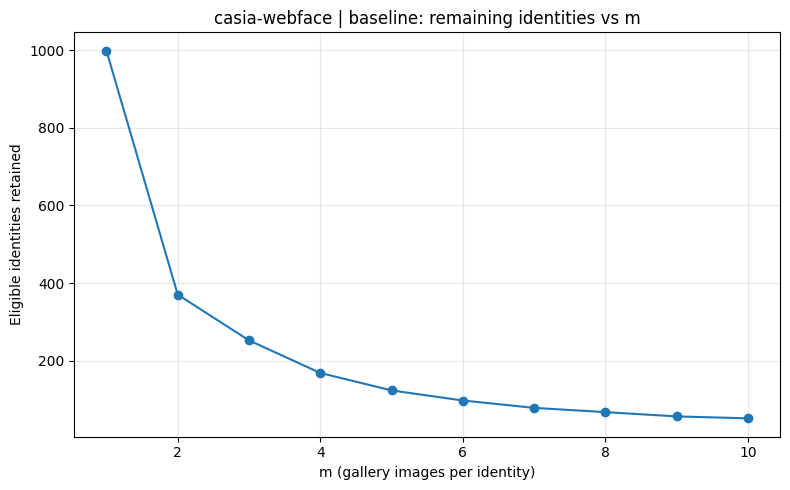

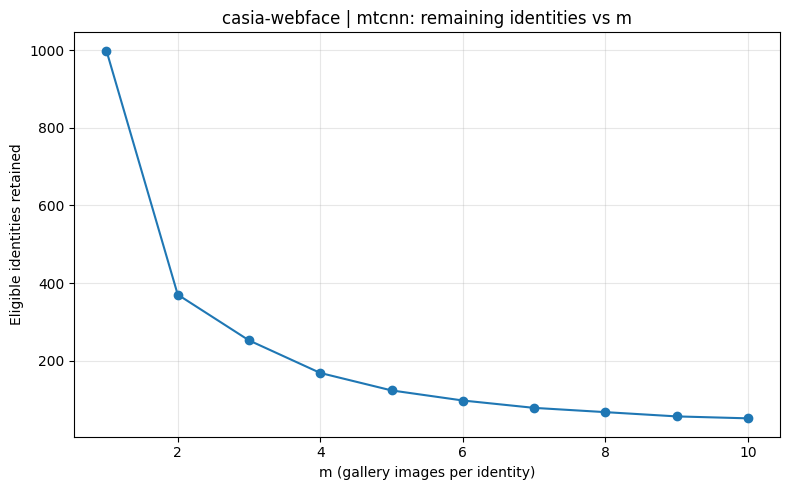

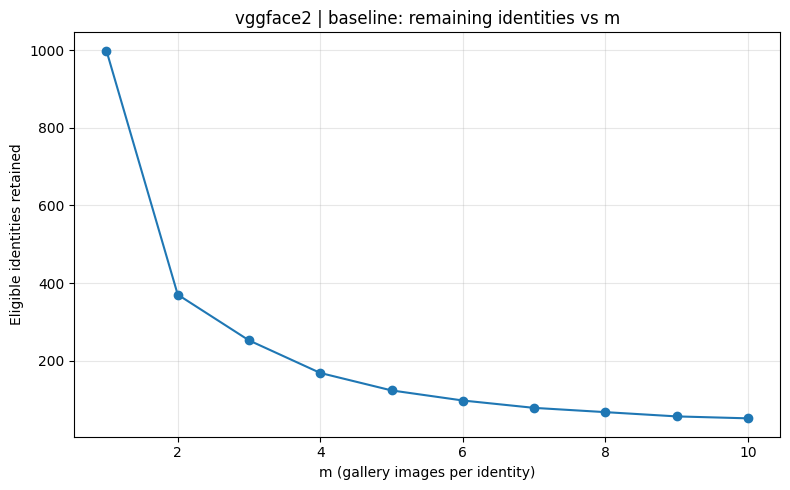

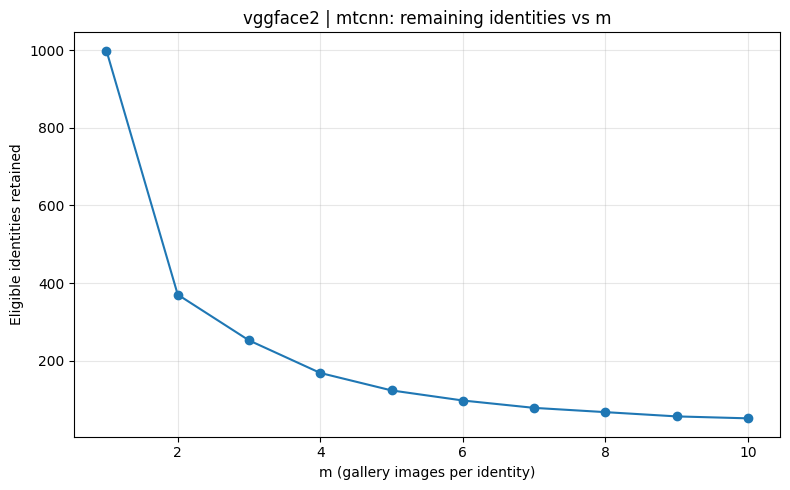

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

def _find_coverage_source():
    preferred = [
        "agg_df",
        "results_df",
        "all_results_df",
        "coverage_df",
        "coverage_tradeoff_df",
        "coverage_tradeoff_results_df",
    ]

    for name in preferred:
        if name in globals() and isinstance(globals()[name], pd.DataFrame):
            df = globals()[name]
            if {"m", "n_identities"}.issubset(df.columns):
                return name, df.copy()

    for name, obj in globals().items():
        if isinstance(obj, pd.DataFrame) and {"m", "n_identities"}.issubset(obj.columns):
            return name, obj.copy()

    raise RuntimeError(
        "Could not find a dataframe with columns {'m', 'n_identities'}. "
        "Run the Task 4 aggregation cells first."
    )

source_name, plot_df = _find_coverage_source()
print(f"Using dataframe: {source_name}")

# If both experiments are present, keep only the coverage-tradeoff rows
if "experiment" in plot_df.columns:
    mask = plot_df["experiment"].astype(str).str.contains("coverage", case=False, na=False)
    if mask.any():
        plot_df = plot_df[mask].copy()

# Average over repeated seeds if needed
group_cols = [c for c in ["model", "preprocessing", "variant", "m"] if c in plot_df.columns]
if group_cols:
    plot_df = (
        plot_df.groupby(group_cols, as_index=False)["n_identities"]
        .mean()
        .sort_values("m")
    )
else:
    plot_df = plot_df.sort_values("m")

prep_col = None
if "preprocessing" in plot_df.columns:
    prep_col = "preprocessing"
elif "variant" in plot_df.columns:
    prep_col = "variant"

if "model" in plot_df.columns and prep_col is not None:
    for model_name in sorted(plot_df["model"].dropna().unique()):
        for prep_name in sorted(plot_df[prep_col].dropna().unique()):
            sub = plot_df[
                (plot_df["model"] == model_name) &
                (plot_df[prep_col] == prep_name)
            ].sort_values("m")

            if sub.empty:
                continue

            plt.figure(figsize=(8, 5))
            plt.plot(sub["m"], sub["n_identities"], marker="o")
            plt.xlabel("m (gallery images per identity)")
            plt.ylabel("Eligible identities retained")
            plt.title(f"{model_name} | {prep_name}: remaining identities vs m")
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

elif "model" in plot_df.columns:
    for model_name in sorted(plot_df["model"].dropna().unique()):
        sub = plot_df[plot_df["model"] == model_name].sort_values("m")

        if sub.empty:
            continue

        plt.figure(figsize=(8, 5))
        plt.plot(sub["m"], sub["n_identities"], marker="o")
        plt.xlabel("m (gallery images per identity)")
        plt.ylabel("Eligible identities retained")
        plt.title(f"{model_name}: remaining identities vs m")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

else:
    plt.figure(figsize=(8, 5))
    plt.plot(plot_df["m"], plot_df["n_identities"], marker="o")
    plt.xlabel("m (gallery images per identity)")
    plt.ylabel("Eligible identities retained")
    plt.title("Remaining identities vs m")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()